<a href="https://colab.research.google.com/github/RuchirS-spec/qmlhep/blob/main/task9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {device}")

using device: cpu


In [9]:
# we normalize the images so the pixel values are nicely scaled for the neural network
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

print("downloading data...") # download datasets
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# create data loaders to feed the data in batches
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)

print(f"total training images: {len(train_dataset)}")
print(f"total testing images: {len(test_dataset)}")

downloading data...
total training images: 60000
total testing images: 10000


In [10]:
class ChebyKANLayer(nn.Module): # building a single kolmogorov-arnold layer
    def __init__(self, in_features, out_features, degree=4):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.degree = degree

        # the standard base path (acts like a normal linear layer)
        self.base_linear = nn.Linear(in_features, out_features, bias=False)
        self.base_activation = nn.SiLU() # silu is the standard activation used in kans

        # the kan path (learnable polynomial coefficients on the edges)
        # we need a coefficient for every input, every output, and every polynomial degree
        self.poly_coeffs = nn.Parameter(torch.randn(out_features, in_features, degree + 1))

        self.poly_coeffs.data *= 1.0 / (in_features * (degree + 1)) # scale down the initial random weights so training doesn't explode

    def forward(self, x):
        base_output = self.base_linear(self.base_activation(x)) # calculate the standard base output

        # normalize the inputs to be strictly between -1 and 1
        # (chebyshev polynomials go crazy if inputs are outside this range)
        x_norm = torch.tanh(x)

        # compute the chebyshev polynomials step-by-step
        # t_0(x) = 1
        # t_1(x) = x
        # t_n(x) = 2x * t_{n-1}(x) - t_{n-2}(x)
        T = [torch.ones_like(x_norm), x_norm]

        for i in range(2, self.degree + 1):
            next_T = 2 * x_norm * T[-1] - T[-2]
            T.append(next_T)


        T_stacked = torch.stack(T, dim=-1)


        kan_output = torch.einsum('bid,oid->bo', T_stacked, self.poly_coeffs)

        return base_output + kan_output

In [11]:
class SimpleMNISTKAN(nn.Module): # stacking the layers to build the mnist model
    def __init__(self):
        super().__init__()
        self.layer1 = ChebyKANLayer(in_features=784, out_features=64, degree=4)

        self.norm1 = nn.LayerNorm(64) # layer normalization

        self.layer2 = ChebyKANLayer(in_features=64, out_features=10, degree=4)

    def forward(self, x):
        x = x.view(x.size(0), -1) # flatten the 2d image

        x = self.layer1(x)
        x = self.norm1(x)
        x = self.layer2(x)

        return x

model = SimpleMNISTKAN().to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"model created! total learnable parameters: {total_params:,}")

model created! total learnable parameters: 305,024


In [12]:
criterion = nn.CrossEntropyLoss() # standard cross-entropy loss
optimizer = optim.AdamW(model.parameters(), lr=0.001) # adamw

epochs = 20
loss_history = []

print("starting training loop...\n")

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        predictions = model(images)

        loss = criterion(predictions, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)h
    loss_history.append(avg_loss)
    print(f"epoch [{epoch+1}/{epochs}] completed. average loss: {avg_loss:.4f}")

print("\ntraining finished!")

starting training loop...

epoch [1/20] completed. average loss: 0.3843
epoch [2/20] completed. average loss: 0.1551
epoch [3/20] completed. average loss: 0.1115
epoch [4/20] completed. average loss: 0.0868
epoch [5/20] completed. average loss: 0.0728
epoch [6/20] completed. average loss: 0.0611
epoch [7/20] completed. average loss: 0.0493
epoch [8/20] completed. average loss: 0.0423
epoch [9/20] completed. average loss: 0.0368
epoch [10/20] completed. average loss: 0.0315
epoch [11/20] completed. average loss: 0.0286
epoch [12/20] completed. average loss: 0.0228
epoch [13/20] completed. average loss: 0.0234
epoch [14/20] completed. average loss: 0.0199
epoch [15/20] completed. average loss: 0.0198
epoch [16/20] completed. average loss: 0.0146
epoch [17/20] completed. average loss: 0.0170
epoch [18/20] completed. average loss: 0.0124
epoch [19/20] completed. average loss: 0.0122
epoch [20/20] completed. average loss: 0.0127

training finished!


final test accuracy: 97.22%


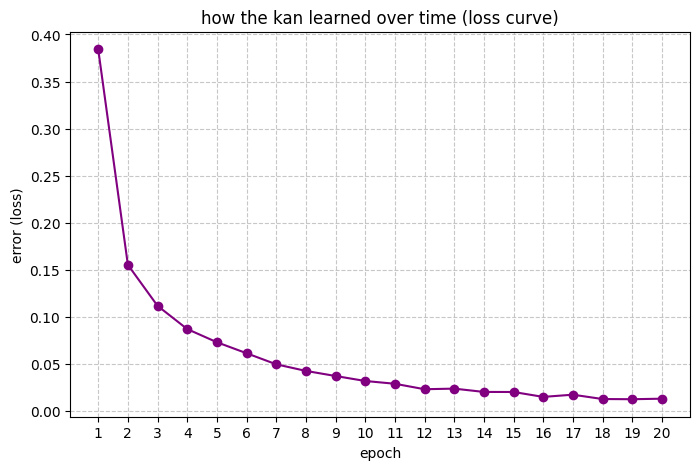

In [13]:
model.eval() # evaluate the model on unseen data (turns off dropout, etc. if we had any)
correct_guesses = 0
total_samples = 0

with torch.no_grad(): # we don't need gradients for testing, this saves memory and speeds things up
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        _, predicted_classes = torch.max(outputs, dim=1) # the output is a bunch of probabilities, we take the highest one as the guess

        total_samples += labels.size(0)
        correct_guesses += (predicted_classes == labels).sum().item()

accuracy = (correct_guesses / total_samples) * 100
print(f"final test accuracy: {accuracy:.2f}%")

# plot the training loss to see how it improved over time
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_history, marker='o', color='purple')
plt.title('how the kan learned over time (loss curve)')
plt.xlabel('epoch')
plt.ylabel('error (loss)')
plt.xticks(range(1, epochs + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()